# Bayes' Rule

This notebook explains **Bayes' Rule**, a fundamental theorem in probability that describes how to update the probability of a hypothesis based on new evidence. It is a cornerstone of machine learning and statistics.

## Deriving Bayes' Rule

Bayes' Rule is derived from the product rule of probability. We know there are two ways to express the joint probability $P(X, Y)$:

1.  $P(X, Y) = P(X|Y)P(Y)$
2.  $P(X, Y) = P(Y|X)P(X)$

Since both expressions are equal to the same joint probability, we can set them equal to each other:

$P(Y|X)P(X) = P(X|Y)P(Y)$

By rearranging this equation to solve for $P(Y|X)$, we get Bayes' Rule.

## The Rule and Its Components

**Bayes' Rule** is formally stated as:

$P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}$

This formula allows us to "invert" a conditional probability. If we know $P(X|Y)$, we can find $P(Y|X)$. Each component has a special name:

- **Posterior ($P(Y|X)$):** The probability of our hypothesis Y *after* seeing the evidence X. This is what we want to compute.
- **Likelihood ($P(X|Y)$):** The probability of observing the evidence X *given* that our hypothesis Y is true.
- **Prior ($P(Y)$):** The initial probability of our hypothesis Y *before* seeing any evidence.
- **Evidence ($P(X)$):** The marginal probability of observing the evidence X.

## The Expanded Form

The evidence, $P(X)$, can be calculated by marginalizing the joint probability over all possible values of Y:

$P(X) = \sum_{y} P(X, y) = \sum_{y} P(X|y)P(y)$

Substituting this into the denominator gives the expanded form of Bayes' Rule, which is often used in practice:

$P(Y|X) = \frac{P(X|Y)P(Y)}{\sum_{y} P(X|y)P(y)}$

This form is useful because it allows us to calculate the posterior using only the likelihood and the prior.

## Example: Using Bayes' Rule

Let's use our colored shapes data to calculate $P(\text{Shape=S} | \text{Color=R})$ using Bayes' Rule.

We need:
1.  **Likelihood ($P(\text{Color=R} | \text{Shape=S})$)**
2.  **Prior ($P(\text{Shape=S})$)**
3.  **Evidence ($P(\text{Color=R})$)**

We will calculate these from our tables and then apply the rule.

In [1]:
import pandas as pd

# Data from previous notebooks
counts = pd.DataFrame(
    [[18, 12, 30],
     [16, 20, 4]],
    index=['Shape=S', 'Shape=C'],
    columns=['Color=R', 'Color=G', 'Color=B']
)

joint_prob = counts / counts.values.sum()

# Calculate marginals
marginal_shape = joint_prob.sum(axis=1)
marginal_color = joint_prob.sum(axis=0)

# Calculate conditional P(Color | Shape)
cond_prob_color_given_shape = joint_prob.divide(marginal_shape, axis=0)

# --- Apply Bayes' Rule to find P(Shape=S | Color=R) ---

# 1. Likelihood: P(Color=R | Shape=S)
likelihood = cond_prob_color_given_shape.loc['Shape=S', 'Color=R']

# 2. Prior: P(Shape=S)
prior = marginal_shape.loc['Shape=S']

# 3. Evidence: P(Color=R)
evidence = marginal_color.loc['Color=R']

# Bayes' Rule calculation
posterior = (likelihood * prior) / evidence

print(f"Likelihood P(Color=R | Shape=S) = {likelihood:.4f}")
print(f"Prior P(Shape=S) = {prior:.4f}")
print(f"Evidence P(Color=R) = {evidence:.4f}")
print("---")
print(f"Posterior P(Shape=S | Color=R) = ({likelihood:.4f} * {prior:.4f}) / {evidence:.4f} = {posterior:.4f}")

# --- Verification ---
# Calculate P(Shape | Color) directly for comparison
cond_prob_shape_given_color = joint_prob.T.divide(marginal_color, axis=0).T
actual_posterior = cond_prob_shape_given_color.loc['Shape=S', 'Color=R']
print(f"\\nDirect Calculation for Verification: {actual_posterior:.4f}")
print(f"Verification: {'Success' if abs(posterior - actual_posterior) < 1e-9 else 'Failure'}")

Likelihood P(Color=R | Shape=S) = 0.3000
Prior P(Shape=S) = 0.6000
Evidence P(Color=R) = 0.3400
---
Posterior P(Shape=S | Color=R) = (0.3000 * 0.6000) / 0.3400 = 0.5294
\nDirect Calculation for Verification: 0.5294
Verification: Success


## Illustration of Bayes' Rule

Imagine a population represented by a square. The prior probability of an event Y, $P(Y)$, is the fraction of the area covered by Y.

When we get new evidence X, we are restricting our focus to the area where X is true. Bayes' rule tells us how to find the proportion of that *new area* that is also covered by Y.

It essentially re-normalizes our updated belief ($P(X|Y)P(Y)$) by the total probability of the evidence ($P(X)$) to ensure the result is a valid probability.

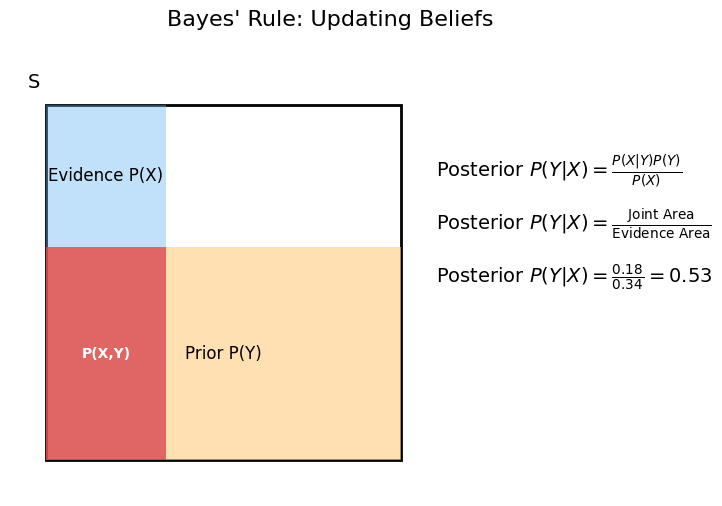

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 6))

# --- Define areas (probabilities) ---
prior_y = 0.6
evidence_x = 0.34
likelihood_x_given_y = 0.3
# From product rule: joint_xy = likelihood * prior
joint_xy = likelihood_x_given_y * prior_y

# --- Draw rectangles ---
# Sample space
ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=2))
ax.text(-0.05, 1.05, 'S', fontsize=14)

# Prior P(Y)
ax.add_patch(patches.Rectangle((0, 0), 1, prior_y, facecolor='#ffcc80', alpha=0.6))
ax.text(0.5, prior_y / 2, 'Prior P(Y)', ha='center', va='center', fontsize=12)

# Evidence P(X)
ax.add_patch(patches.Rectangle((0, 0), evidence_x, 1, facecolor='#64b5f6', alpha=0.4))
ax.text(evidence_x / 2, 0.8, 'Evidence P(X)', ha='center', va='center', fontsize=12)

# Joint P(X,Y) - the intersection
ax.add_patch(patches.Rectangle((0, 0), evidence_x, prior_y, facecolor='red', alpha=0.5))
ax.text(evidence_x / 2, prior_y / 2, 'P(X,Y)', ha='center', va='center', fontsize=10, color='white', weight='bold')


# --- Annotations ---
ax.set_title("Bayes' Rule: Updating Beliefs", fontsize=16)
ax.text(1.1, 0.8, f'Posterior $P(Y|X) = \\frac{{P(X|Y)P(Y)}}{{P(X)}}$', fontsize=14)
ax.text(1.1, 0.65, f'Posterior $P(Y|X) = \\frac{{\\text{{Joint Area}}}}{{\\text{{Evidence Area}}}}$', fontsize=14)
ax.text(1.1, 0.5, f'Posterior $P(Y|X) = \\frac{{{joint_xy:.2f}}}{{{evidence_x:.2f}}} = {(joint_xy/evidence_x):.2f}$', fontsize=14)


ax.set_xlim(-0.1, 1.7)
ax.set_ylim(-0.1, 1.2)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

## Summary

- **Bayes' Rule** provides a way to update our beliefs about a hypothesis (Y) in light of new evidence (X).
- **Formula:** $P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}$
- It connects the **posterior** probability to the **prior**, **likelihood**, and **evidence**.
- It is a fundamental tool for inference in machine learning, used in algorithms like Naive Bayes classifiers and Bayesian networks.